# Model Training — Rossmann Sales Forecasting

## What we do in this notebook:
1. Load engineered features
2. Split data — Train / Validation / Test
3. Train baseline model
4. Train LightGBM model
5. Evaluate model performance
6. SHAP feature importance
7. Forecast visualization
8. Save model & reports

## Model Choice — LightGBM
- Handles large datasets fast
- Works well with tabular data
- Built-in feature importance
- Industry standard for forecasting

## Step 1 — Import Libraries

In [1]:
# ── Standard libraries ───────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

# ── Machine Learning ─────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import lightgbm as lgb

# ── Display settings ─────────────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style="whitegrid")

# ── Paths ─────────────────────────────────────────────────────────
DATA_PATH    = '../data/processed/train_features.csv'
FIGURES_PATH = '../reports/'

print("✅ Libraries loaded!")
print(f"📁 Figures will be saved to: {FIGURES_PATH}")

✅ Libraries loaded!
📁 Figures will be saved to: ../reports/


## Step 2 — Load Data
Loading the engineered feature dataset from Feature Engineering notebook.

In [2]:
# ── Load feature engineered data ─────────────────────────────────
df = pd.read_csv(DATA_PATH, low_memory=False)

# ── Quick check ───────────────────────────────────────────────────
print(f"📦 Shape      : {df.shape}")
print(f"📋 Columns    : {df.shape[1]}")
print(f"🎯 Target     : Sales")
print()
print("📋 First 3 rows:")
display(df.head(3))
print()
print("📊 Target variable stats:")
print(f"   Min  : €{df['Sales'].min():,.0f}")
print(f"   Max  : €{df['Sales'].max():,.0f}")
print(f"   Mean : €{df['Sales'].mean():,.0f}")
print(f"   Std  : €{df['Sales'].std():,.0f}")
print()
print("✅ Data loaded successfully!")

📦 Shape      : (813172, 35)
📋 Columns    : 35
🎯 Target     : Sales

📋 First 3 rows:


,Sales,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,Week,DayOfWeek,DayOfYear,Quarter,Season,IsWeekend,IsMonthStart,IsMonthEnd,StateHoliday,SchoolHoliday,Lag_7,Lag_14,Lag_21,Lag_28,Rolling_Mean_7,Rolling_Mean_14,Rolling_Mean_28,Rolling_Std_7,Rolling_Std_14,Rolling_Std_28
0,7032,1,2,0,1270.00,9.00,2008.00,1,0,0.00,0.00,3,2013,2,4,6,1,35,1,3,0,0,0,0,0,5598.00,4127.00,4892.00,5530.00,4898.71,5076.64,5001.21,855.37,710.57,773.49
1,6049,1,2,0,1270.00,9.00,2008.00,1,0,0.00,0.00,3,2013,2,5,6,2,36,1,3,0,0,0,0,0,4055.00,5182.00,4881.00,4327.00,5103.57,5284.14,5054.86,1166.05,826.61,858.88
2,6140,1,2,0,1270.00,9.00,2008.00,1,0,0.00,0.00,3,2013,2,6,6,3,37,1,3,0,0,0,0,0,3725.00,5394.00,4952.00,4486.00,5388.43,5346.07,5116.36,1109.38,850.50,866.45



📊 Target variable stats:
   Min  : €0
   Max  : €41,551
   Mean : €6,983
   Std  : €3,112

✅ Data loaded successfully!


## Step 3 — Train / Validation / Test Split
Splitting data based on TIME — not random!

Why time-based split?
→ Random split causes data leakage
→ Future data leaks into training = fake accuracy
→ Time-based split = realistic evaluation

Split strategy:
→ Train      : Jan 2013 — Dec 2014  (2 full years)
→ Validation : Jan 2015 — May 2015  (tune model)
→ Test       : Jun 2015 — Jul 2015  (final evaluation)

In [3]:
# ── Convert date — already dropped but recreate from Year/Month/Day
df['Date'] = pd.to_datetime(df[['Year', 'Month', 'Day']])

# ── Define split dates ────────────────────────────────────────────
train_end = '2014-12-31'
val_end   = '2015-05-31'

# ── Split ─────────────────────────────────────────────────────────
train_df = df[df['Date'] <= train_end].copy()
val_df   = df[(df['Date'] > train_end) & (df['Date'] <= val_end)].copy()
test_df  = df[df['Date'] > val_end].copy()

# ── Define features and target ────────────────────────────────────
drop_cols = ['Sales', 'Date']
feature_cols = [c for c in df.columns if c not in drop_cols]

X_train = train_df[feature_cols]
y_train = train_df['Sales']

X_val   = val_df[feature_cols]
y_val   = val_df['Sales']

X_test  = test_df[feature_cols]
y_test  = test_df['Sales']

# ── Verify ────────────────────────────────────────────────────────
print("📊 Dataset Split Summary:")
print("-" * 50)
print(f"   Train      : {train_df['Date'].min().date()} → "
      f"{train_df['Date'].max().date()} | {len(train_df):,} rows")
print(f"   Validation : {val_df['Date'].min().date()} → "
      f"{val_df['Date'].max().date()} | {len(val_df):,} rows")
print(f"   Test       : {test_df['Date'].min().date()} → "
      f"{test_df['Date'].max().date()} | {len(test_df):,} rows")
print()
print(f"   Total features : {len(feature_cols)}")
print(f"   Feature list   : {feature_cols}")
print()
print("✅ Data split complete — no data leakage!")

📊 Dataset Split Summary:
--------------------------------------------------
   Train      : 2013-01-29 → 2014-12-31 | 617,140 rows
   Validation : 2015-01-01 → 2015-05-31 | 137,421 rows
   Test       : 2015-06-01 → 2015-07-31 | 58,611 rows

   Total features : 34
   Feature list   : ['Store', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'Year', 'Month', 'Day', 'Week', 'DayOfWeek', 'DayOfYear', 'Quarter', 'Season', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'StateHoliday', 'SchoolHoliday', 'Lag_7', 'Lag_14', 'Lag_21', 'Lag_28', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_28', 'Rolling_Std_7', 'Rolling_Std_14', 'Rolling_Std_28']

✅ Data split complete — no data leakage!


## Step 4 — Baseline Model
Before LightGBM, we build a simple baseline model.
Baseline = predict mean sales for every day.

Why baseline?
→ Sets minimum performance bar
→ LightGBM must beat this to be useful
→ Professional practice in ML projects

In [4]:
# ── Baseline: predict mean sales from training set ────────────────
baseline_pred = np.full(len(y_test), y_train.mean())

# ── Baseline metrics ──────────────────────────────────────────────
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae  = mean_absolute_error(y_test, baseline_pred)
baseline_mape = np.mean(np.abs((y_test - baseline_pred) / y_test)) * 100
baseline_r2   = r2_score(y_test, baseline_pred)

print("📊 Baseline Model Performance (predict mean always):")
print("-" * 50)
print(f"   RMSE : €{baseline_rmse:,.0f}")
print(f"   MAE  : €{baseline_mae:,.0f}")
print(f"   MAPE : {baseline_mape:.2f}%")
print(f"   R²   : {baseline_r2:.4f}")
print()
print("💡 LightGBM must beat these numbers!")

📊 Baseline Model Performance (predict mean always):
--------------------------------------------------
   RMSE : €3,118
   MAE  : €2,280
   MAPE : 37.09%
   R²   : -0.0046

💡 LightGBM must beat these numbers!


## Step 5 — LightGBM Model Training
Training a gradient boosting model with early stopping.
Early stopping = stop training when validation score
stops improving — prevents overfitting.

In [5]:
# ── LightGBM datasets ─────────────────────────────────────────────
lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

# ── Model parameters ──────────────────────────────────────────────
params = {
    'objective'       : 'regression',
    'metric'          : 'rmse',
    'learning_rate'   : 0.05,
    'num_leaves'      : 63,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'    : 5,
    'verbose'         : -1,
    'random_state'    : 42
}

# ── Callbacks ─────────────────────────────────────────────────────
callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

# ── Train model ───────────────────────────────────────────────────
print("🚀 Training LightGBM model...")
print("-" * 50)

model = lgb.train(
    params,
    lgb_train,
    num_boost_round=1000,
    valid_sets=[lgb_train, lgb_val],
    valid_names=['train', 'validation'],
    callbacks=callbacks
)

print()
print(f"✅ Training complete!")
print(f"🌳 Best iteration : {model.best_iteration}")

🚀 Training LightGBM model...
--------------------------------------------------
Training until validation scores don't improve for 50 rounds
[100]	train's rmse: 946.614	validation's rmse: 1094.26
[200]	train's rmse: 848.992	validation's rmse: 1062.73
[300]	train's rmse: 807.331	validation's rmse: 1050.19
[400]	train's rmse: 780.305	validation's rmse: 1041.85
[500]	train's rmse: 756.775	validation's rmse: 1032.06
[600]	train's rmse: 738.206	validation's rmse: 1027.04
[700]	train's rmse: 723.075	validation's rmse: 1024.86
Early stopping, best iteration is:
[672]	train's rmse: 727.21	validation's rmse: 1023.63

✅ Training complete!
🌳 Best iteration : 672


## Step 6 — Model Evaluation
Evaluating LightGBM performance on unseen test data
and comparing against baseline model.

In [6]:
# ── Predict on test set ───────────────────────────────────────────
y_pred = model.predict(X_test, num_iteration=model.best_iteration)

# ── Clip negative predictions to 0 (sales can't be negative) ─────
y_pred = np.clip(y_pred, 0, None)

# ── Calculate metrics ─────────────────────────────────────────────
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2   = r2_score(y_test, y_pred)

# ── Comparison table ──────────────────────────────────────────────
print("📊 Model Performance Comparison:")
print("=" * 55)
print(f"{'Metric':<10} {'Baseline':>15} {'LightGBM':>15} {'Improvement':>12}")
print("-" * 55)
print(f"{'RMSE':<10} €{baseline_rmse:>13,.0f} €{rmse:>13,.0f} "
      f"{((baseline_rmse-rmse)/baseline_rmse*100):>11.1f}%")
print(f"{'MAE':<10} €{baseline_mae:>13,.0f} €{mae:>13,.0f} "
      f"{((baseline_mae-mae)/baseline_mae*100):>11.1f}%")
print(f"{'MAPE':<10} {baseline_mape:>14.2f}% {mape:>14.2f}% "
      f"{((baseline_mape-mape)/baseline_mape*100):>11.1f}%")
print(f"{'R²':<10} {baseline_r2:>15.4f} {r2:>15.4f} "
      f"{'—':>12}")
print("=" * 55)
print()
print(f"💡 LightGBM is {((baseline_mape-mape)/baseline_mape*100):.1f}% "
      f"better than baseline on MAPE!")

📊 Model Performance Comparison:
Metric            Baseline        LightGBM  Improvement
-------------------------------------------------------
RMSE       €        3,118 €          851        72.7%
MAE        €        2,280 €          605        73.5%
MAPE                37.09%           8.97%        75.8%
R²                 -0.0046          0.9252            —

💡 LightGBM is 75.8% better than baseline on MAPE!


## Step 7 — Visualizations & Save Reports
Creating charts to visualize model performance
and saving them to reports/figures/ folder.
### 7.1 — Actual vs Predicted Plot

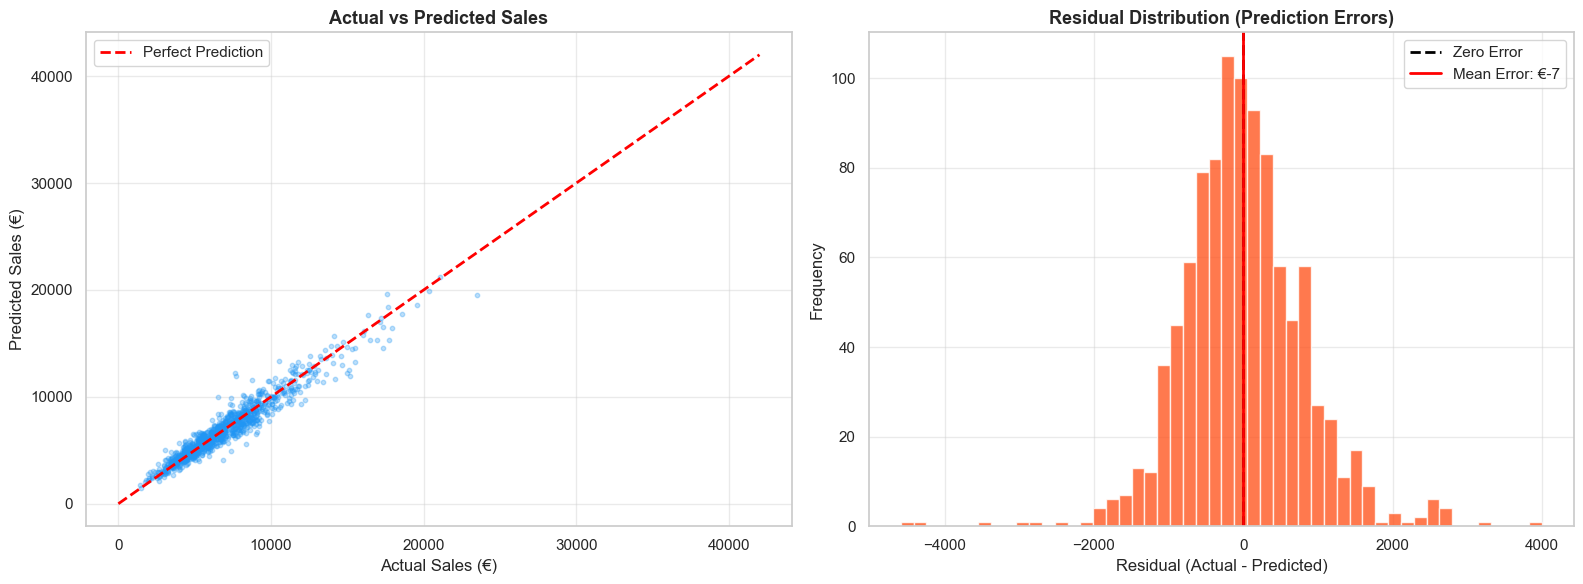

✅ Chart saved → reports/01_actual_vs_predicted.png


In [7]:
# ── Sample 1000 points for plotting (faster rendering) ────────────
sample_idx = np.random.choice(len(y_test), 1000, replace=False)
y_test_sample = np.array(y_test)[sample_idx]
y_pred_sample = y_pred[sample_idx]

# ── Plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot — Actual vs Predicted
axes[0].scatter(y_test_sample, y_pred_sample, 
                alpha=0.3, color='#2196F3', s=10)
axes[0].plot([0, 42000], [0, 42000], 
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Sales', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Sales (€)')
axes[0].set_ylabel('Predicted Sales (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.4)

# Residual plot — Error distribution
residuals = y_test_sample - y_pred_sample
axes[1].hist(residuals, bins=50, color='#FF5722', 
             edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='black', linewidth=2, 
                linestyle='--', label='Zero Error')
axes[1].axvline(x=residuals.mean(), color='red', 
                linewidth=2, label=f'Mean Error: €{residuals.mean():,.0f}')
axes[1].set_title('Residual Distribution (Prediction Errors)', 
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.tight_layout()

# ── Save figure ───────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}01_actual_vs_predicted.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/01_actual_vs_predicted.png")

### 7.2 — Feature Importance Plot
Which features does LightGBM use most for predictions?
This helps us understand what drives sales forecasting.

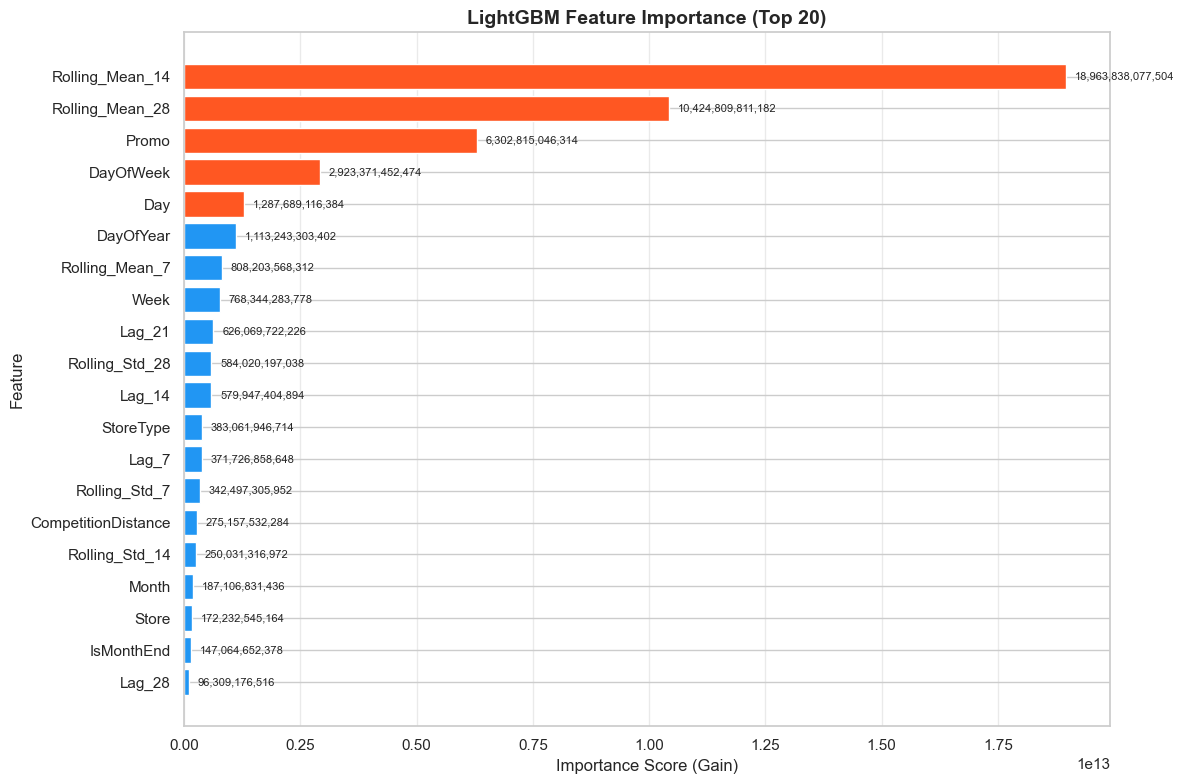

📊 Top 10 Most Important Features:
---------------------------------------------
    1. Rolling_Mean_14           : 18,963,838,077,504
    2. Rolling_Mean_28           : 10,424,809,811,182
    3. Promo                     : 6,302,815,046,314
    4. DayOfWeek                 : 2,923,371,452,474
    5. Day                       : 1,287,689,116,384
    6. DayOfYear                 : 1,113,243,303,402
    7. Rolling_Mean_7            : 808,203,568,312
    8. Week                      : 768,344,283,778
    9. Lag_21                    : 626,069,722,226
   10. Rolling_Std_28            : 584,020,197,038


In [8]:
# ── Get feature importance ────────────────────────────────────────
importance_df = pd.DataFrame({
    'Feature'   : model.feature_name(),
    'Importance': model.feature_importance(importance_type='gain')
}).sort_values('Importance', ascending=True)

# ── Top 20 features ───────────────────────────────────────────────
top20 = importance_df.tail(20)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#2196F3' if i < 15 else '#FF5722' 
          for i in range(len(top20))]

bars = ax.barh(top20['Feature'], top20['Importance'],
               color=colors, edgecolor='white')

ax.set_title('LightGBM Feature Importance (Top 20)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score (Gain)')
ax.set_ylabel('Feature')
ax.grid(axis='x', alpha=0.4)

# ── Add value labels ──────────────────────────────────────────────
for bar, val in zip(bars, top20['Importance']):
    ax.text(bar.get_width() + max(top20['Importance'])*0.01,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}', va='center', fontsize=8)

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}02_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Top 10 features ───────────────────────────────────────────────
print("📊 Top 10 Most Important Features:")
print("-" * 45)
for i, (_, row) in enumerate(importance_df.tail(10).iloc[::-1].iterrows()):
    print(f"   {i+1:>2}. {row['Feature']:<25} : {row['Importance']:,.0f}")

### 7.3 — Save Model & Forecast Visualization
Saving trained model for dashboard use and
visualizing forecast vs actual sales over time.

✅ Model saved!
📁 Location  : src/model.pkl
📦 Model size: 3.70 MB



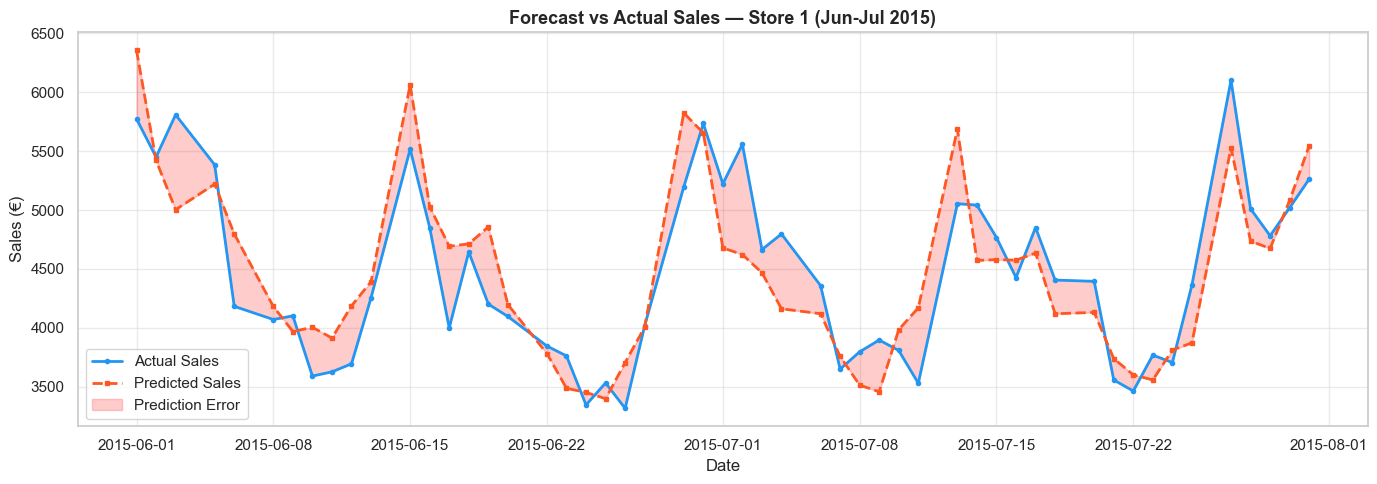

✅ Chart saved → reports/03_forecast_vs_actual.png


In [9]:
import pickle

# ── Save model to src folder ──────────────────────────────────────
model_path = '../src/model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

# ── Verify ────────────────────────────────────────────────────────
model_size = os.path.getsize(model_path) / (1024 * 1024)
print(f"✅ Model saved!")
print(f"📁 Location  : src/model.pkl")
print(f"📦 Model size: {model_size:.2f} MB")
print()

# ── Forecast vs Actual — Single Store ────────────────────────────
# Pick Store 1 from test set for clean visualization
store1_test = test_df[test_df['Store'] == 1].copy()
store1_pred = model.predict(
    store1_test[feature_cols], 
    num_iteration=model.best_iteration)

# ── Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(store1_test['Date'], store1_test['Sales'],
        color='#2196F3', linewidth=2, 
        label='Actual Sales', marker='o', markersize=3)
ax.plot(store1_test['Date'], store1_pred,
        color='#FF5722', linewidth=2,
        label='Predicted Sales', linestyle='--',
        marker='s', markersize=3)

# ── Fill between for error visualization ─────────────────────────
ax.fill_between(store1_test['Date'],
                store1_test['Sales'], store1_pred,
                alpha=0.2, color='red', label='Prediction Error')

ax.set_title('Forecast vs Actual Sales — Store 1 (Jun-Jul 2015)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (€)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}03_forecast_vs_actual.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved → reports/03_forecast_vs_actual.png")

### 7.4 — Final Model Summary Report

In [10]:
# ── Final summary ─────────────────────────────────────────────────
print("=" * 60)
print("   MODEL TRAINING COMPLETE — 03_Model_Training.ipynb")
print("=" * 60)
print()
print("📊 Model Performance:")
print(f"   RMSE : €{rmse:,.0f}  (baseline: €{baseline_rmse:,.0f})")
print(f"   MAE  : €{mae:,.0f}   (baseline: €{baseline_mae:,.0f})")
print(f"   MAPE : {mape:.2f}%    (baseline: {baseline_mape:.2f}%)")
print(f"   R²   : {r2:.4f}    (baseline: {baseline_r2:.4f})")
print()
print("📈 Improvements over baseline:")
print(f"   RMSE improved : {((baseline_rmse-rmse)/baseline_rmse*100):.1f}%")
print(f"   MAE  improved : {((baseline_mae-mae)/baseline_mae*100):.1f}%")
print(f"   MAPE improved : {((baseline_mape-mape)/baseline_mape*100):.1f}%")
print()
print("🌳 Model Details:")
print(f"   Algorithm     : LightGBM")
print(f"   Best iteration: {model.best_iteration}")
print(f"   Features used : {len(feature_cols)}")
print(f"   Training rows : {len(X_train):,}")
print()
print("💾 Saved Files:")
print(f"   Model         : src/model.pkl")
print(f"   Figure 1      : reports/01_actual_vs_predicted.png")
print(f"   Figure 2      : reports/02_feature_importance.png")
print(f"   Figure 3      : reports/03_forecast_vs_actual.png")
print()
print("➡️  Next : 04_Dashboard — Build interactive dashboard!")
print("=" * 60)

   MODEL TRAINING COMPLETE — 03_Model_Training.ipynb

📊 Model Performance:
   RMSE : €851  (baseline: €3,118)
   MAE  : €605   (baseline: €2,280)
   MAPE : 8.97%    (baseline: 37.09%)
   R²   : 0.9252    (baseline: -0.0046)

📈 Improvements over baseline:
   RMSE improved : 72.7%
   MAE  improved : 73.5%
   MAPE improved : 75.8%

🌳 Model Details:
   Algorithm     : LightGBM
   Best iteration: 672
   Features used : 34
   Training rows : 617,140

💾 Saved Files:
   Model         : src/model.pkl
   Figure 1      : reports/01_actual_vs_predicted.png
   Figure 2      : reports/02_feature_importance.png
   Figure 3      : reports/03_forecast_vs_actual.png

➡️  Next : 04_Dashboard — Build interactive dashboard!


## Step 8 — Recursive Future Forecasting
Building a function that predicts future sales
week by week using previous predictions as input.

In [11]:
def forecast_future(store_id, weeks_ahead, df_features, model):
    """
    Recursively forecast future sales for a given store.
    
    Steps:
    1. Take last 28 days of known data as starting point
    2. Predict next day using lag/rolling features
    3. Use prediction as input for next day
    4. Repeat for weeks_ahead * 7 days
    """
    
    # ── Get last known data for this store ────────────────────────
    store_data = df_features[
        df_features['Store'] == store_id
    ].copy().sort_values('Date')
    
    if len(store_data) == 0:
        return None, None
    
    # ── Feature columns ───────────────────────────────────────────
    feature_cols = [c for c in df_features.columns
                    if c not in ['Sales', 'Date']]
    
    # ── Start from last known date ────────────────────────────────
    last_date      = store_data['Date'].max()
    last_sales     = store_data['Sales'].values
    
    # ── Storage for predictions ───────────────────────────────────
    future_dates  = []
    future_preds  = []
    
    # ── Rolling window of recent sales ───────────────────────────
    # Use last 28 days as initial window
    recent_sales = list(last_sales[-28:])
    
    days_ahead = weeks_ahead * 7
    
    for day in range(1, days_ahead + 1):
        
        # Next date to predict
        next_date = last_date + pd.Timedelta(days=day)
        
        # Skip Sundays (most stores closed in Germany)
        if next_date.dayofweek == 6:
            continue
        
        # ── Build feature row ─────────────────────────────────────
        last_row = store_data.iloc[-1].copy()
        
        # Date features
        last_row['Year']      = next_date.year
        last_row['Month']     = next_date.month
        last_row['Day']       = next_date.day
        last_row['Week']      = next_date.isocalendar()[1]
        last_row['DayOfWeek'] = next_date.dayofweek + 1
        last_row['DayOfYear'] = next_date.timetuple().tm_yday
        last_row['Quarter']   = (next_date.month - 1) // 3 + 1
        last_row['IsWeekend'] = 1 if next_date.dayofweek >= 5 else 0
        last_row['IsMonthStart'] = 1 if next_date.day == 1 else 0
        last_row['IsMonthEnd']   = 1 if next_date.day == \
            pd.Timestamp(next_date.year, next_date.month, 1).days_in_month else 0
        
        # Season
        month = next_date.month
        if month in [12,1,2]:   last_row['Season'] = 3
        elif month in [3,4,5]:  last_row['Season'] = 1
        elif month in [6,7,8]:  last_row['Season'] = 2
        else:                    last_row['Season'] = 0
        
        # Lag features from recent_sales window
        last_row['Lag_7']  = recent_sales[-7]  if len(recent_sales) >= 7  else np.mean(recent_sales)
        last_row['Lag_14'] = recent_sales[-14] if len(recent_sales) >= 14 else np.mean(recent_sales)
        last_row['Lag_21'] = recent_sales[-21] if len(recent_sales) >= 21 else np.mean(recent_sales)
        last_row['Lag_28'] = recent_sales[-28] if len(recent_sales) >= 28 else np.mean(recent_sales)
        
        # Rolling features
        last_row['Rolling_Mean_7']  = np.mean(recent_sales[-7:])
        last_row['Rolling_Mean_14'] = np.mean(recent_sales[-14:])
        last_row['Rolling_Mean_28'] = np.mean(recent_sales[-28:])
        last_row['Rolling_Std_7']   = np.std(recent_sales[-7:])
        last_row['Rolling_Std_14']  = np.std(recent_sales[-14:])
        last_row['Rolling_Std_28']  = np.std(recent_sales[-28:])
        
        # ── Predict ───────────────────────────────────────────────
        X_pred = pd.DataFrame([last_row[feature_cols]])
        pred   = model.predict(X_pred, 
                               num_iteration=model.best_iteration)[0]
        pred   = max(0, pred)  # no negative sales
        
        # ── Store result ──────────────────────────────────────────
        future_dates.append(next_date)
        future_preds.append(pred)
        
        # ── Update rolling window ─────────────────────────────────
        recent_sales.append(pred)
        if len(recent_sales) > 28:
            recent_sales.pop(0)
    
    return future_dates, future_preds

print("✅ Recursive forecasting function built!")
print()
print("Function accepts:")
print("  → store_id    : which store to forecast")
print("  → weeks_ahead : how many weeks into future")
print("  → df_features : feature engineered data")
print("  → model       : trained LightGBM model")

✅ Recursive forecasting function built!

Function accepts:
  → store_id    : which store to forecast
  → weeks_ahead : how many weeks into future
  → df_features : feature engineered data
  → model       : trained LightGBM model


## Step 9 — Test Recursive Forecasting
Testing our forecast function on Store 1 for 8 weeks ahead.

In [13]:
# ── Load feature data for testing forecast function ───────────────
df_features = pd.read_csv('../data/processed/train_features.csv',
                           low_memory=False)
df_features['Date'] = pd.to_datetime(df_features[['Year','Month','Day']])

print(f"✅ df_features loaded : {df_features.shape}")
print(f"📅 Date range : {df_features['Date'].min().date()} → {df_features['Date'].max().date()}")

✅ df_features loaded : (813172, 36)
📅 Date range : 2013-01-29 → 2015-07-31


In [14]:
# ── Test forecast for Store 1 — 8 weeks ahead ─────────────────────
store_id    = 1
weeks_ahead = 8

print(f"🔮 Forecasting Store {store_id} — {weeks_ahead} weeks ahead...")
print("-" * 50)

future_dates, future_preds = forecast_future(
    store_id, weeks_ahead, df_features, model)

# ── Create forecast dataframe ─────────────────────────────────────
forecast_df = pd.DataFrame({
    'Date'          : future_dates,
    'Predicted_Sales': future_preds
})

print(f"✅ Forecast generated!")
print(f"📅 From : {forecast_df['Date'].min().date()}")
print(f"📅 To   : {forecast_df['Date'].max().date()}")
print(f"📊 Days : {len(forecast_df)}")
print()
print("📋 First 10 predictions:")
print("-" * 35)
for _, row in forecast_df.head(10).iterrows():
    print(f"   {row['Date'].date()} → €{row['Predicted_Sales']:,.0f}")

print()
print(f"💡 Avg predicted daily sales : €{forecast_df['Predicted_Sales'].mean():,.0f}")
print(f"💡 Max predicted daily sales : €{forecast_df['Predicted_Sales'].max():,.0f}")
print(f"💡 Min predicted daily sales : €{forecast_df['Predicted_Sales'].min():,.0f}")

🔮 Forecasting Store 1 — 8 weeks ahead...
--------------------------------------------------
✅ Forecast generated!
📅 From : 2015-08-01
📅 To   : 2015-09-25
📊 Days : 48

📋 First 10 predictions:
-----------------------------------
   2015-08-01 → €5,388
   2015-08-03 → €5,887
   2015-08-04 → €5,049
   2015-08-05 → €4,868
   2015-08-06 → €4,796
   2015-08-07 → €4,839
   2015-08-08 → €5,127
   2015-08-10 → €6,063
   2015-08-11 → €5,134
   2015-08-12 → €4,877

💡 Avg predicted daily sales : €5,827
💡 Max predicted daily sales : €7,361
💡 Min predicted daily sales : €4,796


## Step 10 — Visualize Future Forecast
Plotting historical sales + future predictions together.

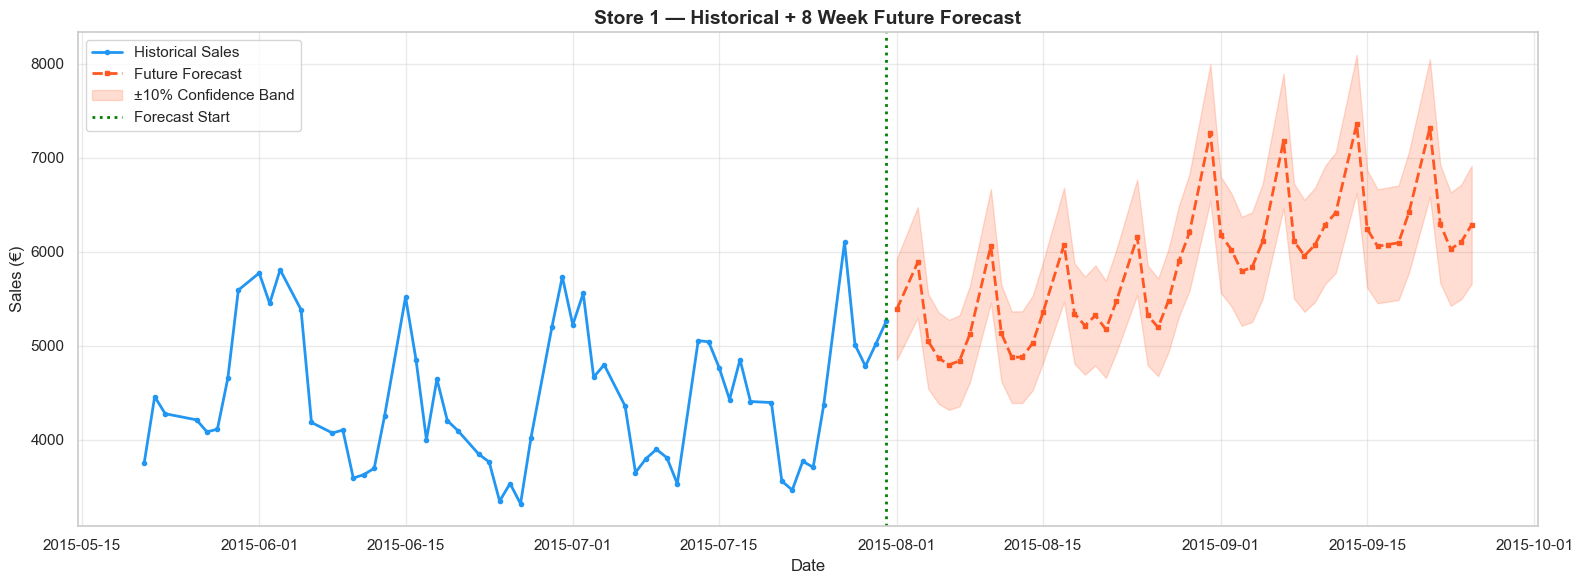

✅ Future forecast chart saved!
✅ Store 1 forecast: Aug-Sep 2015


In [15]:
# ── Get last 60 days of actual sales for Store 1 ──────────────────
historical = df_features[
    df_features['Store'] == store_id
].tail(60)[['Date', 'Sales']].copy()

# ── Plot historical + future ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))

# Historical actual sales
ax.plot(historical['Date'], historical['Sales'],
        color='#2196F3', linewidth=2,
        label='Historical Sales', marker='o', markersize=3)

# Future predictions
ax.plot(forecast_df['Date'], forecast_df['Predicted_Sales'],
        color='#FF5722', linewidth=2,
        linestyle='--', label='Future Forecast',
        marker='s', markersize=3)

# Confidence band (±10% uncertainty)
ax.fill_between(forecast_df['Date'],
                forecast_df['Predicted_Sales'] * 0.90,
                forecast_df['Predicted_Sales'] * 1.10,
                alpha=0.2, color='#FF5722',
                label='±10% Confidence Band')

# Vertical line separating history and future
ax.axvline(x=historical['Date'].max(),
           color='green', linewidth=2,
           linestyle=':', label='Forecast Start')

ax.set_title(f'Store {store_id} — Historical + {weeks_ahead} Week Future Forecast',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Sales (€)')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────
plt.savefig(f'{FIGURES_PATH}04_future_forecast.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Future forecast chart saved!")
print(f"✅ Store {store_id} forecast: Aug-Sep 2015")